# Modify the list of ligands and receptors for a pathway

In this notebook, we show how to modify the default set of ligads and receptors used for CCC inference. By default, scRICH uses the ligand/receptor database of Cellchat (CallchatDB), which can be found [here](https://github.com/jinworks/CellChat). This database is also included within the scRICH package and updated based on CellcahtDB updates.

First, we run preprocessing commands until an overview of the main CCC pathways is computed - these steps are explained in details in *Notebook 1-CCC-analysis*.

### 0-Package import

In [1]:
import scvelo as scv
import scanpy as sc
import os
import string
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2
import scrich as ri

### 1-Data loading and preprocessing

In [2]:
import warnings
warnings.simplefilter("ignore", DeprecationWarning)

In [3]:
adata = scv.datasets.gastrulation_erythroid()

In [4]:
scv.pp.filter_and_normalize(adata, min_shared_counts=20)
scv.pp.moments(adata, n_pcs=30, n_neighbors=30)

Filtered out 47456 genes that are detected 20 counts (shared).
Normalized count data: X, spliced, unspliced.
Logarithmized X.
computing neighbors


/Users/federicobocci/Desktop/commflow_project/ccc_project/commflow_env/lib/python3.9/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)
/var/folders/h8/221dz5dn3t7fnjtc80l_3p7c0000gn/T/ipykernel_7716/3097972183.py:2: DeprecationWarning: Automatic neighbor calculation is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors first with Scanpy.
  scv.pp.moments(adata, n_pcs=30, n_neighbors=30)
/Users/federicobocci/Desktop/commflow_project/ccc_project/commflow_env/lib/python3.9/site-packages/scvelo/preprocessing/moments.py:71: DeprecationWarning: `neighbors` is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors with Scanpy.
  neighbors(


    finished (0:00:08) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:02) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


### 2-Initial analysis of CCC heterogeneity

In [5]:
ri.tl.pathways_overview(adata, human=False)

Scanning for cell-cell communication pathways...
Identified 11 pathways with at least one Receptor and one Ligand detected


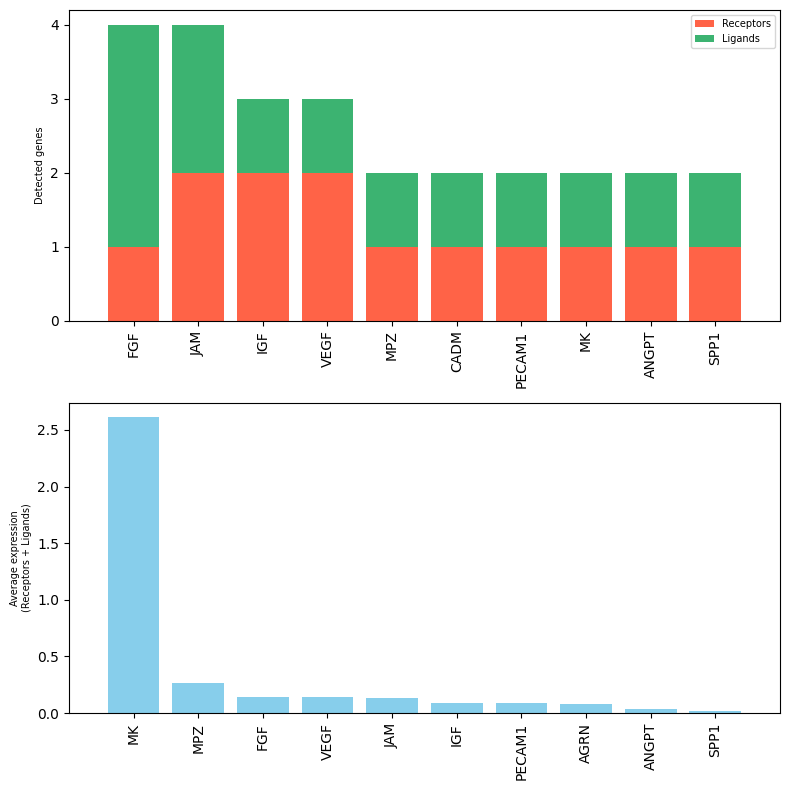

In [6]:
ri.pl.pathways_overview(adata, top=10, ticksize=10, savefig=False, showfig=True)

### 3-Modify L/R set for a specific pathway

*adata.uns['pathways']* contains information about ligands and receptors used for individual CCC pathways. *adata.uns['pathways']* is generated when running *cf.tl.pathways_overview()*. For example, for the VEGF pathway, the following ligands and receptors are found based on the overlap between the CellchatDB database and the geneset in this dataset:

In [7]:
adata.uns['pathways']['VEGF']

{'receptors': ['Flt1', 'Kdr'], 'ligands': ['Vegfb']}

It mihgt be desirable to overwrite the set of ligands and receptors used to identify CCC signaling modes, for example because the database might be incomplete, or to account for joint activity of two CCC pathways that are strongly related to each other. The set of receptors and ligands of a CCC pathway are stored as adictionary and can be modified accordingly. For example, we can enforce that only the *Flt1* receptor is used:

In [8]:
adata.uns['pathways']['VEGF'] = ['Flt1']
adata.uns['pathways']['VEGF']

['Flt1']

After this modificartion, you can run the *cf.tl.all_path_sim()* (see Notebook 1). Note that running the *cf.tl.pathways_overview* command again will overwrite your modification to *adata.uns['pathways']*. So, it is suggested to first run *adata.uns['pathways']* to gather information about the main pathways, receptors, and ligands in your database, and then modify *adata.uns['pathways']*.